# Lab 4 - GANs and Autoencoders

### Welcome to this lab notebook on image exploration using CNNs, GANs and Autoenconders. 

Let's get started!

**The following code cover, generally speaking, the same tasks you completed for Lab 3 - Implementing CNNs using the CIFAR-10 dataset**

Using device: cuda
AdvancedCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool

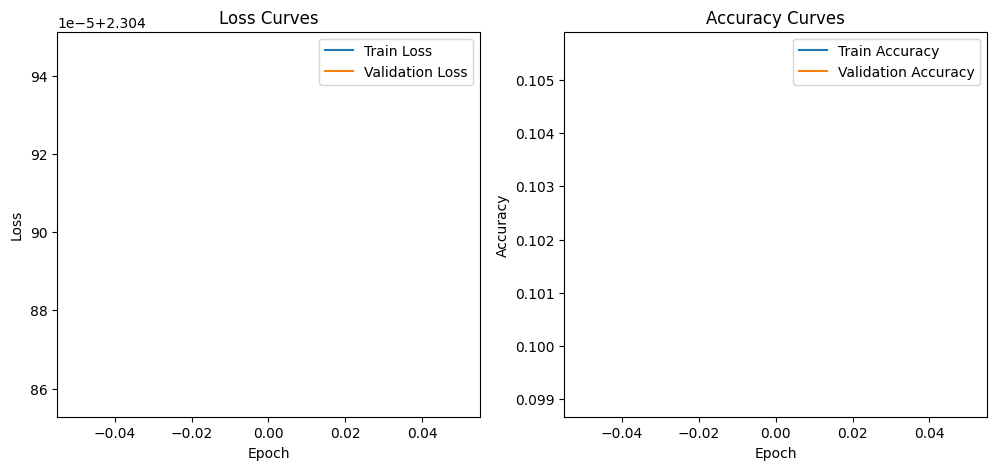

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# -------------------------------
# 1. Device Setup
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# 2. Data Loading and Preprocessing
# -------------------------------
# Data augmentation and normalization for training
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])
# For testing/validation: only convert to tensor and normalize.
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

# Download CIFAR-10 datasets.
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Create a validation split (10% of training data)
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# -------------------------------
# 3. Define the Advanced CNN Model
# -------------------------------
class AdvancedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AdvancedCNN, self).__init__()
        # Convolutional Block 1
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  
            nn.BatchNorm2d(32),                             
            nn.ReLU(inplace=True),                          
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  
            nn.Dropout(0.2)
        )
        # Convolutional Block 2
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )
        # Convolutional Block 3
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.4)
        )
        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4, 128),   # 32x32 becomes 4x4 after three poolings.
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

model = AdvancedCNN(num_classes=10).to(device)
print(model)

# -------------------------------
# 4. Training Strategies and Optimization
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=100)

# Early Stopping Setup
early_stopping_patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0

num_epochs = 1  # For demonstration; increase for better performance.
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Training and Validation Loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation Phase
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / total_val
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered.")
            break

# Load the best model state
model.load_state_dict(best_model_state)

# -------------------------------
# 5. Evaluate the Model on the Test Set
# -------------------------------
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
test_loss /= total_test
test_acc = correct_test / total_test
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Plot training and validation curves.
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.show()

The following code performs several advanced visualizations and analyses for a CNN model trained on CIFAR-10. It first retrieves and displays a test image by iterating through the dataset, unnormalizing it, and rendering it using Matplotlib. Next, it visualizes **convolutional filters** learned by different layers of the model, extracting weights and displaying them to show how the network processes image features. To interpret model decisions, it applies **Grad-CAM**, generating heatmaps that highlight important image regions influencing classification. Additionally, it demonstrates an **FGSM adversarial attack**, where a small perturbation alters the image enough to mislead the model into incorrect predictions. Finally, the script utilizes a **pre-trained Fully Convolutional Network (FCN)** for image segmentation, applying it to an example image and displaying the resulting segmentation mask.


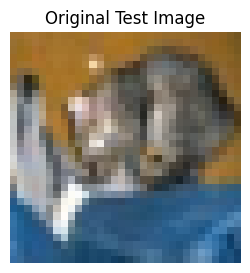

Visualizing filters from conv_block1:


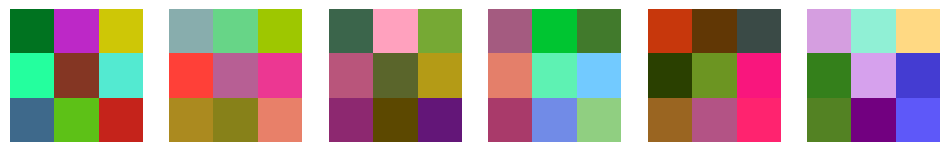

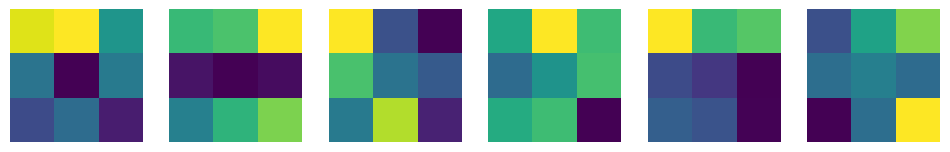

Visualizing filters from conv_block2:


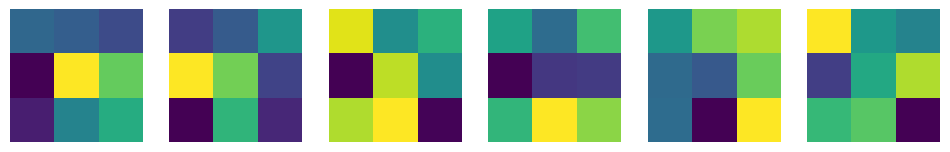

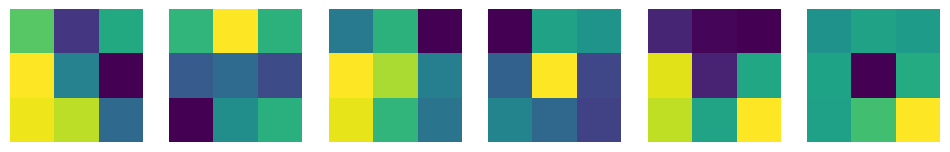

Visualizing filters from conv_block3:


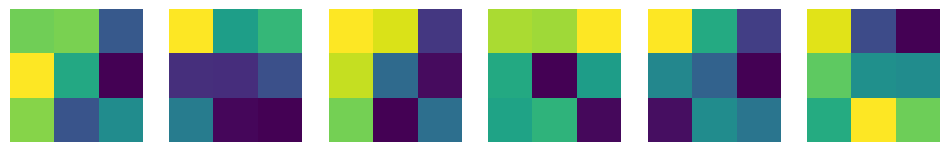

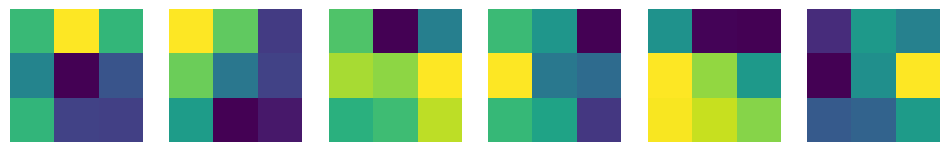

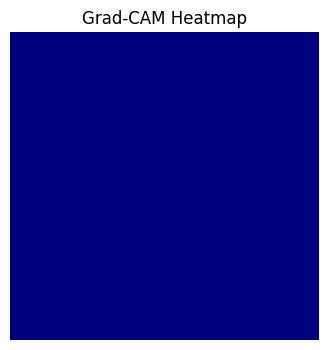

In [6]:
import cv2                # For image resizing and color mapping (Grad-CAM)
import requests           # To download sample images for segmentation

# =============================================================================
# Extended Visualizations and Analyses
# =============================================================================

# CIFAR-10 dataset normalization parameters used for image preprocessing.
# These values are obtained from the dataset's statistics and help standardize
# the images before feeding them into the neural network.
cifar_mean = np.array([0.4914, 0.4822, 0.4465])  # Mean values for each RGB channel
cifar_std  = np.array([0.2470, 0.2435, 0.2616])  # Standard deviation for each RGB channel

# ---------------------------------------------------------------------------
# 1. Show an Original Image from the Test Set
# ---------------------------------------------------------------------------

def unnormalize(img_tensor, mean, std):
    """
    Reverses the normalization applied during preprocessing to restore the original image values.
    This is useful for visualization, as deep learning models often use normalized inputs,
    which may not be human interpretable.
    """
    img = img_tensor.numpy().transpose(1, 2, 0)  # Convert PyTorch tensor to NumPy array and reorder dimensions
    img = std * img + mean  # Denormalize using mean and std deviation values
    img = np.clip(img, 0, 1)  # Ensure values remain in the valid image range [0,1]
    return img

# Retrieve a batch of test images and labels from the data loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Select the first image from the batch and unnormalize it for visualization
orig_img_tensor = images[0].cpu()
orig_img = unnormalize(orig_img_tensor, cifar_mean, cifar_std)

# Display the original test image without normalization artifacts
plt.figure(figsize=(3,3))
plt.imshow(orig_img)
plt.title("Original Test Image")
plt.axis("off")
plt.show()

# ---------------------------------------------------------------------------
# 2. Visualize Some Trained Filters in Each Convolutional Layer
# ---------------------------------------------------------------------------

def plot_conv_filters(conv_layer, num_filters=6):
    """
    Extracts and visualizes a few filters from a given convolutional layer.
    Convolutional filters help detect features such as edges, textures, and patterns
    in different parts of the image. Early layers detect basic features,
    while deeper layers capture more complex structures.
    """
    filters = conv_layer.weight.data.clone().cpu()  # Retrieve filter weights from the model
    n_filters = min(num_filters, filters.shape[0])  # Limit the number of displayed filters
    
    fig, axes = plt.subplots(1, n_filters, figsize=(n_filters*2, 2))
    for i in range(n_filters):
        filt = filters[i]
        if filt.shape[0] == 3:  # If filter has 3 channels (RGB)
            filt = filt.numpy().transpose(1, 2, 0)  # Change dimensions to match image format
            filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)  # Normalize filter values
        else:  # If filter has a single channel, average the values
            filt = filt.mean(0).numpy()
            filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        axes[i].imshow(filt, cmap='viridis')  # Display the filter
        axes[i].axis('off')
    plt.show()

# Visualize filters from different convolutional blocks
print("Visualizing filters from conv_block1:")
for layer in model.conv_block1:
    if isinstance(layer, nn.Conv2d):
        plot_conv_filters(layer, num_filters=6)

print("Visualizing filters from conv_block2:")
for layer in model.conv_block2:
    if isinstance(layer, nn.Conv2d):
        plot_conv_filters(layer, num_filters=6)

print("Visualizing filters from conv_block3:")
for layer in model.conv_block3:
    if isinstance(layer, nn.Conv2d):
        plot_conv_filters(layer, num_filters=6)

# ---------------------------------------------------------------------------
# 3. Visualize Grad-CAM Saliency Maps from the Last Convolutional Layer
# ---------------------------------------------------------------------------

class GradCAM:
    """
    Implements the Grad-CAM (Gradient-weighted Class Activation Mapping) method.
    Grad-CAM helps visualize which parts of an image contribute most to the model's decision,
    allowing us to interpret CNN predictions and understand how the model makes decisions.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()
    
    def _register_hooks(self):
        """
        Attaches forward and backward hooks to capture activations and gradients.
        These hooks allow us to retrieve the feature maps and their corresponding gradients
        needed for computing the importance of each activation map.
        """
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        
        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))
    
    def generate(self, input_image, target_class=None):
        """
        Computes the Grad-CAM heatmap based on backpropagated gradients.
        The heatmap highlights image regions that have the highest impact on the model's prediction.
        """
        self.model.zero_grad()
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        loss = output[0, target_class]
        loss.backward()
        
        weights = self.gradients.mean(dim=[2,3], keepdim=True)  # Compute gradient-based weights
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # Apply Grad-CAM formula
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam
    
    def remove_hooks(self):
        """
        Removes hooks after visualization to avoid memory leaks.
        This is necessary to prevent unnecessary memory usage when visualizing multiple images.
        """
        for handle in self.hook_handles:
            handle.remove()

# Select a layer from conv_block3 to apply Grad-CAM visualization
target_layer = model.conv_block3[3]
grad_cam = GradCAM(model, target_layer)

# Generate Grad-CAM activation heatmap
cam_map = grad_cam.generate(images[0:1].to(device))
cam_map = cam_map.cpu().squeeze().numpy()

# Upsample the heatmap and overlay onto the original image
cam_map_up = cv2.resize(cam_map, (32, 32))
cam_map_up = np.uint8(255 * cam_map_up)
cam_heatmap = cv2.applyColorMap(cam_map_up, cv2.COLORMAP_JET)

# Display results
plt.figure(figsize=(10, 4))
plt.imshow(cam_map, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()
grad_cam.remove_hooks()

## Now, let's play with GANs

**The following code will allow you to understand how to implement GANs. Engage with the code and complete the reflective questions included in the comments**



Starting GAN training...


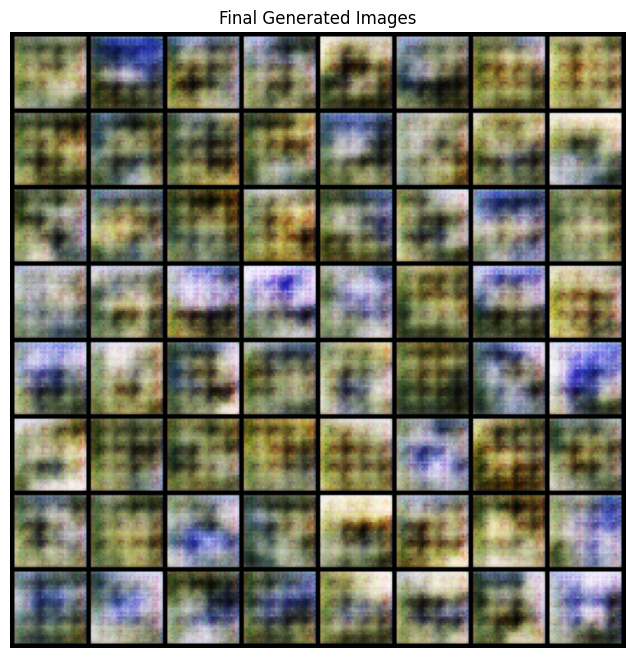

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Part 1: Generative Adversarial Networks (GANs)
# =============================================================================

# Define transformation for the dataset
# Convert images to tensors and normalize them to [-1,1] for better stability in training
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
# Reflective Question: Why might normalizing images to the range [-1,1] be beneficial for training a GAN?
# Answer: Normalizing to [-1,1] helps stabilize training by centering data around zero, making gradients more stable and allowing the Tanh activation in the generator to utilize its full range effectively.

# Load CIFAR-10 dataset for training the GAN
# CIFAR-10 contains 60,000 color images (32x32 pixels) in 10 classes
# Here, we only use the training set
dataset_gan = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_gan)
dataloader_gan = torch.utils.data.DataLoader(dataset_gan, batch_size=128, shuffle=True, num_workers=2)
# Reflective Question: How does shuffling the data and setting an appropriate batch size help in training neural networks?
# Answer: Shuffling prevents the model from learning patterns based on data order and ensures diverse batches. Appropriate batch size balances gradient stability with computational efficiency.

# Set the size of the latent noise vector, which is the input to the generator
nz = 100  # The generator takes a 100-dimensional noise vector as input
# Reflective Question: What is the purpose of feeding random noise into the generator in a GAN?
# Answer: Random noise provides the source of randomness for generating diverse outputs. It allows the generator to create different images from the same model by sampling from different points in the latent space.

# -----------------------------------------------
# 1.1 Define the Generator Network (DCGAN-style)
# -----------------------------------------------
class Generator(nn.Module):
    def __init__(self, nz):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # First layer: Transpose convolution to increase spatial resolution
            nn.ConvTranspose2d(nz, 256, 4, 1, 0, bias=False),  # Output: (256) x 4 x 4
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # Reflective Question: How does a transpose convolution differ from a regular convolution, and why is it used here?
            # Answer: Transpose convolution (deconvolution) increases spatial dimensions while regular convolution decreases them. It's used here to progressively upsample the noise vector into a full-sized image.

            # Second layer: Expanding image size to 8x8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),   # Output: (128) x 8 x 8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # Reflective Question: What role does Batch Normalization play in the stability of GAN training?
            # Answer: Batch Normalization helps stabilize training by normalizing layer inputs, reducing internal covariate shift, and allowing higher learning rates while preventing gradient vanishing/exploding.

            # Third layer: Expanding image size to 16x16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),    # Output: (64) x 16 x 16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # Reflective Question: How do these layers work together to gradually build up the spatial dimensions of the image?
            # Answer: Each transpose convolution layer doubles the spatial dimensions while reducing channel depth, progressively building from a small dense representation to a full-resolution image.

            # Final layer: Expanding image size to 32x32 (CIFAR-10 size)
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),      # Output: (3) x 32 x 32
            nn.Tanh()  # Tanh activation to scale output to [-1,1]
            # Reflective Question: Why is the Tanh activation function a good choice for the generator's output layer?
            # Answer: Tanh outputs values in [-1,1] range, which matches our input data normalization. This ensures the generated images have the same value range as real images.
        )
    
    def forward(self, input):
        return self.main(input)
        # Reflective Question: What is happening during the forward pass of the generator?
        # Answer: The forward pass transforms random noise through multiple transpose convolution layers, gradually upsampling and adding spatial structure to create a realistic image.

# -----------------------------------------------
# 1.2 Define the Discriminator Network
# -----------------------------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # First layer: Convolution to reduce spatial dimensions
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),  # (64) x 16 x 16
            nn.LeakyReLU(0.2, inplace=True),
            # Reflective Question: Why might LeakyReLU be preferred over ReLU in the discriminator?
            # Answer: LeakyReLU allows small negative values to pass through, preventing dead neurons and providing better gradient flow, which is crucial for stable discriminator training.

            # Second layer: Further reducing size to 8x8
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),  # (128) x 8 x 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # Reflective Question: How does the use of BatchNorm here help with the discriminator's learning process?
            # Answer: BatchNorm stabilizes the discriminator's learning by normalizing inputs, preventing it from becoming too strong too quickly and maintaining balance with the generator.

            # Third layer: Reducing size to 4x4
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),  # (256) x 4 x 4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # Reflective Question: What might be the effect of further reducing the image size in terms of feature extraction?
            # Answer: Further spatial reduction forces the network to extract more abstract and high-level features, enabling it to distinguish between real and fake images based on overall structure rather than just local details.

            # Final layer: Output a single probability value
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),  # Output a single value
            nn.Sigmoid()  # Use Sigmoid to output probability (0-1)
            # Reflective Question: Why do we use a Sigmoid activation in the last layer of the discriminator?
            # Answer: Sigmoid outputs a probability between 0 and 1, representing the discriminator's confidence that the input image is real (1) or fake (0).
        )
    
    def forward(self, input):
        # Reshape the output to a 1D vector for loss computation
        return self.main(input).view(-1)
        # Reflective Question: How does reshaping the discriminator's output facilitate calculating the loss?
        # Answer: Reshaping to 1D creates a single probability value per image, making it compatible with binary cross-entropy loss calculation for real/fake classification.

# -----------------------------------------------
# 1.3 Initialize the Networks and Weights
# -----------------------------------------------
def weights_init(m):
    """Initialize weights with a normal distribution for stable training."""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        # Reflective Question: How does initializing weights from a normal distribution contribute to stable training?
        # Answer: Normal initialization with small variance (0.02) prevents gradients from vanishing or exploding early in training, providing a good starting point for learning.
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
        # Reflective Question: Why might we initialize BatchNorm weights differently than convolutional weights?
        # Answer: BatchNorm weights are scaling factors (initialized near 1.0) and biases are shift parameters (initialized to 0), which helps maintain proper normalization initially.

# Create instances of Generator and Discriminator and move them to GPU ('cuda')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
netG = Generator(nz).to(device)
netD = Discriminator().to(device)


# Apply the weights initialization function to both networks
netG.apply(weights_init)
netD.apply(weights_init)
# Reflective Question: What is the purpose of calling apply() on each network with the weights_init function?
# Answer: apply() recursively applies the weights_init function to all modules in the network, ensuring consistent weight initialization across all layers.

# -----------------------------------------------
# 1.4 Define Loss Function and Optimizers for GAN
# -----------------------------------------------
criterion = nn.BCELoss()  # Binary Cross Entropy Loss for real/fake classification
# Reflective Question: Why is Binary Cross Entropy Loss appropriate for this GAN setup?
# Answer: BCE is perfect for binary classification (real vs fake). It provides strong gradients when predictions are wrong and small gradients when they're correct, encouraging proper learning.

# Adam optimizers for both networks
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
# Reflective Question: How do the chosen learning rate and beta parameters in Adam affect training dynamics?
# Answer: Low learning rate (0.0002) ensures stable training. Beta1=0.5 reduces momentum for more responsive updates, while beta2=0.999 maintains long-term gradient information for stable convergence.

real_label = 1.
fake_label = 0.

# Fixed noise vector to monitor the Generator's progress over time
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
# Reflective Question: What advantages does using a fixed noise vector provide when visualizing the generator's output during training?
# Answer: Fixed noise allows consistent comparison of generated images across epochs, making it easy to observe how the generator improves over time without the variability of different random inputs.

# -----------------------------------------------
# 1.5 Train the GAN
# -----------------------------------------------
num_epochs_GAN = 1
G_losses = []
D_losses = []
img_list = []

print("Starting GAN training...")
for epoch in range(num_epochs_GAN):
    for i, data in enumerate(dataloader_gan, 0):
        # Train Discriminator with real images
        netD.zero_grad()  # Zero out gradients for the discriminator before backpropagation
        real_images, _ = data
        b_size = real_images.size(0)
        real_images = real_images.to(device)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output = netD(real_images)
        errD_real = criterion(output, label)
        errD_real.backward()
        # Reflective Question: Why do we compute the loss on real images first, and what does it signify?
        # Answer: Training on real images first teaches the discriminator to correctly identify authentic data. This establishes a baseline for distinguishing real from fake images.

        # Train Discriminator with fake images generated by Generator
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)
        label.fill_(fake_label)
        # Note: detach() is used so gradients are not backpropagated to the generator here.
        output = netD(fake_images.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()
        # Reflective Question: What is the purpose of detaching the fake images when updating the discriminator?
        # Answer: Detaching prevents gradients from flowing back to the generator during discriminator training, ensuring we only update discriminator weights and maintain separate training phases.

        # Train Generator to generate better fake images
        netG.zero_grad()  # Zero out gradients for the generator
        label.fill_(real_label)  # The generator wants the discriminator to believe its outputs are real
        output = netD(fake_images)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()
        # Reflective Question: Why do we label the generator's output as 'real' when calculating its loss?
        # Answer: The generator's goal is to fool the discriminator into thinking its fake images are real. Using real labels maximizes loss when discriminator correctly identifies fakes, encouraging better generation.

        # (Optional) Store losses and generated images for later visualization and analysis.
        G_losses.append(errG.item())
        D_losses.append((errD_real + errD_fake).item())
    # Reflective Question: How might tracking the generator and discriminator losses over epochs help you understand the training progress?
    # Answer: Loss tracking reveals training dynamics - ideally both losses should decrease and stabilize around similar values, indicating balanced competition between generator and discriminator.

# After training, visualize the final generated images
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Final Generated Images")
grid = torchvision.utils.make_grid(fake_images[:64], padding=2, normalize=True)
plt.imshow(np.transpose(grid.cpu(), (1,2,0)))
plt.show()
# Reflective Question: What changes or improvements in the generated images would you look for as evidence of successful GAN training?
# Answer: Successful training produces sharper, more realistic images with better color consistency, recognizable object structures, and reduced artifacts compared to early training stages.

## Time for Autoencoders!

**The following code will allow you to understand how to implement Autoconders. Engage with the code and complete the reflective questions included in the comments**

Starting Autoencoder training...
Autoencoder Epoch [1/10] Loss: 0.0336
Autoencoder Epoch [2/10] Loss: 0.0098
Autoencoder Epoch [3/10] Loss: 0.0070
Autoencoder Epoch [4/10] Loss: 0.0055
Autoencoder Epoch [5/10] Loss: 0.0048
Autoencoder Epoch [6/10] Loss: 0.0049
Autoencoder Epoch [7/10] Loss: 0.0038
Autoencoder Epoch [8/10] Loss: 0.0034
Autoencoder Epoch [9/10] Loss: 0.0032
Autoencoder Epoch [10/10] Loss: 0.0028


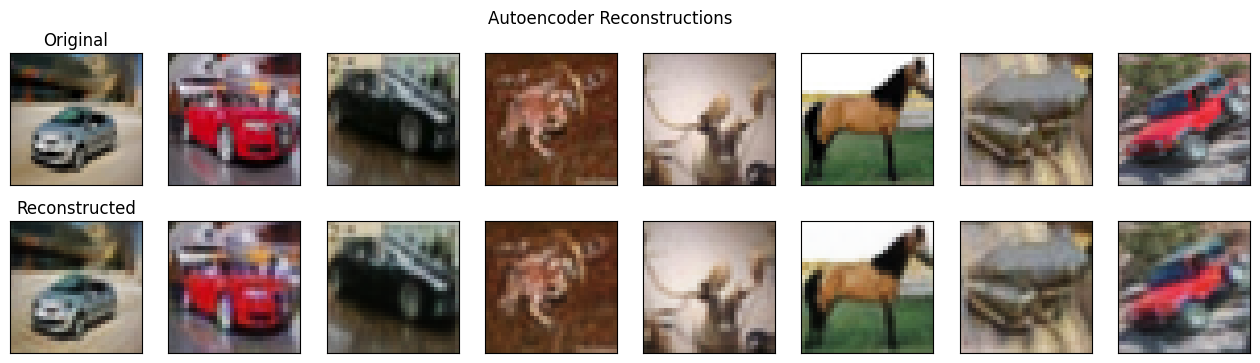

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# =============================================================================
# Part 2: Convolutional Autoencoders
# =============================================================================

# This autoencoder will learn to compress CIFAR-10 images into a latent representation and then reconstruct them.
# The architecture consists of an encoder (to compress) and a decoder (to reconstruct the image).

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder: Compress input image (3x32x32) into a latent representation
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),   # Output: (64 x 16 x 16)
            nn.ReLU(True),
            # Reflective Question: How does using a stride of 2 help in reducing the spatial dimensions of the image?
            # Answer: Stride of 2 makes the convolution kernel skip every other pixel, effectively downsampling the image by half in each dimension, reducing computational load while preserving important features.

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),   # Output: (128 x 8 x 8)
            nn.ReLU(True),
            # Reflective Question: What might be the benefit of increasing the number of channels while reducing the spatial dimensions?
            # Answer: Increasing channels while reducing spatial size allows the network to capture more complex features in a compressed representation, creating a rich latent encoding with more feature diversity.

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # Output: (256 x 4 x 4)
            nn.ReLU(True)
            # Reflective Question: Why might ReLU activations be useful after each convolution in the encoder?
            # Answer: ReLU introduces non-linearity, enabling the network to learn complex mappings and prevents vanishing gradients while being computationally efficient with its simple thresholding operation.
        )
        # Decoder: Reconstruct the image from the latent representation
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: (128 x 8 x 8)
            nn.ReLU(True),
            # Reflective Question: How does ConvTranspose2d help to increase the spatial dimensions of the feature maps?
            # Answer: ConvTranspose2d (deconvolution) reverses the convolution operation by upsampling feature maps, effectively expanding spatial dimensions while learning appropriate feature reconstruction patterns.

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),   # Output: (64 x 16 x 16)
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, kernel_size=3, stride=2, padding=1, output_padding=1),     # Output: (3 x 32 x 32)
            nn.Tanh()  # Activation function to ensure output is in range [-1,1]
            # Reflective Question: Why is Tanh chosen for the final activation instead of, say, ReLU or Sigmoid?
            # Answer: Tanh outputs values in [-1,1] range, matching the normalized input data range. Unlike ReLU (which clips negatives) or Sigmoid ([0,1]), Tanh preserves the full dynamic range of the input normalization.
        )
    
    def forward(self, x):
        latent = self.encoder(x)  # Encode the input image to a latent space
        # Reflective Question: What kind of information do you expect the latent representation to capture about the original image?
        # Answer: The latent representation captures essential features like shapes, edges, colors, and spatial relationships in a compressed form, discarding noise and irrelevant details while preserving information needed for reconstruction.
        recon = self.decoder(latent)  # Decode back to the original image dimensions
        # Reflective Question: How does the decoder utilize the latent features to reconstruct the original image?
        # Answer: The decoder progressively upsamples the latent features through transpose convolutions, gradually rebuilding spatial detail and combining learned features to reconstruct the original image structure.
        return recon

# Create an instance of the autoencoder and move it to the proper device (CPU/GPU)
# Note: 'device' should be defined elsewhere in your code, e.g.:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder().to(device)
# Reflective Question: Why is it important to move the model to the appropriate device before training?
# Answer: Moving to the appropriate device (GPU/CPU) ensures all tensors and computations occur on the same device, preventing device mismatch errors and utilizing available hardware acceleration for faster training.

# Define the loss function (Mean Squared Error for reconstruction quality)
criterion_AE = nn.MSELoss()
# Reflective Question: Why is Mean Squared Error (MSE) a suitable loss function for reconstruction tasks in autoencoders?
# Answer: MSE measures pixel-wise differences between original and reconstructed images, providing a direct measure of reconstruction quality that encourages the autoencoder to minimize visual differences.

# Define the optimizer (Adam optimizer with learning rate 0.001)
optimizer_AE = optim.Adam(autoencoder.parameters(), lr=0.001)
# Reflective Question: How does the choice of optimizer and learning rate influence the training process of the autoencoder?
# Answer: Adam optimizer adapts learning rates for each parameter, providing stable convergence. The learning rate of 0.001 balances training speed with stability, preventing overshooting while ensuring reasonable progress.

# Training loop for the autoencoder
num_epochs_AE = 10  # Increase this number for better reconstructions
ae_losses = []  # Store loss for each epoch

print("Starting Autoencoder training...")
for epoch in range(num_epochs_AE):
    running_loss = 0.0
    for data in dataloader_gan:  # Load images from dataloader
        images, _ = data  # We don't need the labels for reconstruction
        images = images.to(device)  # Move images to device (CPU/GPU)
        optimizer_AE.zero_grad()  # Zero the gradients before the forward pass
        # Reflective Question: Why must we zero out the gradients at the beginning of each training iteration?
        # Answer: Gradients accumulate by default in PyTorch. Zeroing them prevents accumulation from previous iterations, ensuring each batch's gradients are calculated independently for proper parameter updates.

        recon_images = autoencoder(images)  # Forward pass: reconstruct the images
        # Reflective Question: What happens during the forward pass of the autoencoder?
        # Answer: The forward pass encodes input images into a compressed latent representation, then decodes this representation back to image space, learning to preserve essential information through the bottleneck.

        loss_AE = criterion_AE(recon_images, images)  # Compute reconstruction loss
        # Reflective Question: How does comparing the reconstructed images with the original images help the model learn?
        # Answer: The comparison provides a learning signal that drives the autoencoder to minimize reconstruction error, forcing it to learn meaningful feature representations that capture the most important aspects of the input data.

        loss_AE.backward()  # Backpropagation: compute gradients
        optimizer_AE.step()  # Update model parameters based on gradients
        running_loss += loss_AE.item() * images.size(0)  # Accumulate loss weighted by batch size
        # Reflective Question: Why do we multiply the loss by the batch size when accumulating the running loss?
        # Answer: Multiplying by batch size weights the loss contribution proportionally to the number of samples, ensuring larger batches contribute more to the total loss, which is needed for calculating the correct average loss per sample.

    # Compute average loss for the epoch
    epoch_loss = running_loss / len(dataloader_gan.dataset)
    ae_losses.append(epoch_loss)
    print(f"Autoencoder Epoch [{epoch+1}/{num_epochs_AE}] Loss: {epoch_loss:.4f}")
    # Reflective Question: How can tracking the loss over epochs help you understand the learning progress of the autoencoder?
    # Answer: Tracking loss over epochs reveals training dynamics - decreasing loss indicates improving reconstruction quality, while plateaus or increases might suggest convergence, overfitting, or need for hyperparameter adjustment.

# -----------------------------------------------
# Visualize Autoencoder Reconstructions
# -----------------------------------------------
# We'll visualize a batch of original images and their corresponding reconstructions

dataiter = iter(dataloader_gan)
images, _ = next(dataiter)
images = images.to(device)
with torch.no_grad():
    recon_images = autoencoder(images)  # Get reconstructed images
    # Reflective Question: Why do we use 'torch.no_grad()' during the inference phase?
    # Answer: torch.no_grad() disables gradient computation during inference, saving memory and computational resources since we don't need gradients for visualization, only forward pass results.

# Function to unnormalize images from [-1,1] to [0,1] for visualization
def unnormalize_tanh(img_tensor):
    img = (img_tensor.cpu().detach().numpy() + 1) / 2.0  # Convert from [-1,1] to [0,1]
    return img.transpose(0, 2, 3, 1)  # Reorder dimensions to (batch, H, W, C)
# Reflective Question: Why is it necessary to unnormalize the images before displaying them?
# Answer: Images are normalized to [-1,1] for training stability, but display functions expect values in [0,1] range. Unnormalizing converts them back to the proper range for visualization.

orig_imgs = unnormalize_tanh(images)
recon_imgs = unnormalize_tanh(recon_images)

n = 8  # Number of images to display
plt.figure(figsize=(16, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i+1)
    plt.imshow(orig_imgs[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")
    
    # Display reconstructed image
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(recon_imgs[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Reconstructed")

plt.suptitle("Autoencoder Reconstructions")
plt.show()
# Reflective Question: What differences do you observe between the original and reconstructed images, and what might these differences tell you about the autoencoder's performance?
# Answer: Differences reveal what information the autoencoder prioritizes - good reconstruction preserves main shapes and colors but may lose fine details. Blurriness or color shifts indicate areas where the latent representation is insufficient or training needs improvement.